# Induction Head test for Pythia 160m

In [2]:
import sys
sys.path.insert(0, '../..')
from src.models import load_model, unload

### Load Model

In [3]:
model_name = "pythia-2.8b"
model, info = load_model(model_name)

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model pythia-2.8b into HookedTransformer
Loaded pythia-2.8b on mps
  32 layers | 32 heads | d_model=2560 | d_mlp=10240 | parallel attn+MLP


### Baseline Prompt

In [4]:
prompt = "the cat sat the cat"
tokens = model.to_str_tokens(prompt)
logits, cache = model.run_with_cache(prompt)

# Check if L1H12 attends from second "cat" back to "sat"
attn = cache["pattern", 1][0, 12]
print(attn)

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [9.9740e-01, 2.6016e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.4055e-01, 6.0256e-01, 1.5689e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.8210e-07, 3.7164e-03, 9.9474e-01, 1.5450e-03, 0.0000e+00, 0.0000e+00],
        [9.8300e-07, 3.7697e-05, 1.0406e-01, 8.5831e-01, 3.7595e-02, 0.0000e+00],
        [2.9446e-07, 2.9754e-08, 3.3050e-04, 3.4158e-01, 5.6453e-01, 9.3562e-02]],
       device='mps:0')


### Declarative Prompts

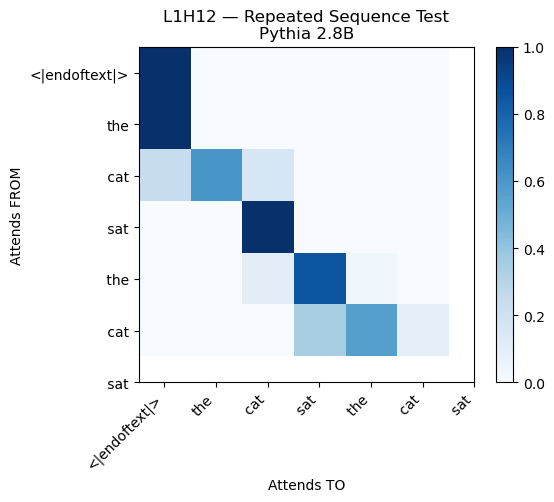

In [5]:
import matplotlib.pyplot as plt
import torch

# Your tensor
attn = cache["pattern", 1][0, 12]

prompt = "the cat sat the cat sat"
tokens = model.to_str_tokens(prompt)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn.cpu().numpy(), cmap="Blues")

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticklabels(tokens)
ax.set_title("L1H12 — Repeated Sequence Test\nPythia 2.8B", fontsize=12)
ax.set_xlabel("Attends TO")
ax.set_ylabel("Attends FROM")

plt.colorbar(im)
plt.tight_layout()
plt.savefig("../paper/figures/L1H12-induction-test.png", dpi=150)
plt.show()

### Evaluative Prompts

In [8]:
alt_tok = model.to_single_token(" alt")
text_tok = model.to_single_token(" text")
skip_tok = model.to_single_token(" skip")
link_tok = model.to_single_token(" link")

alt_text_sim = F.cosine_similarity(
    embed[alt_tok].unsqueeze(0),
    embed[text_tok].unsqueeze(0)
).item()

skip_link_sim = F.cosine_similarity(
    embed[skip_tok].unsqueeze(0),
    embed[link_tok].unsqueeze(0)
).item()

print(f"screen/reader: {screen_reader_sim:.4f}")
print(f"alt/text:      {alt_text_sim:.4f}")
print(f"skip/link:     {skip_link_sim:.4f}")
print(f"cold/water:    {cold_water_sim:.4f}")

screen/reader: 0.0269
alt/text:      0.0601
skip/link:     0.0273
cold/water:    0.0876


### Perplexity

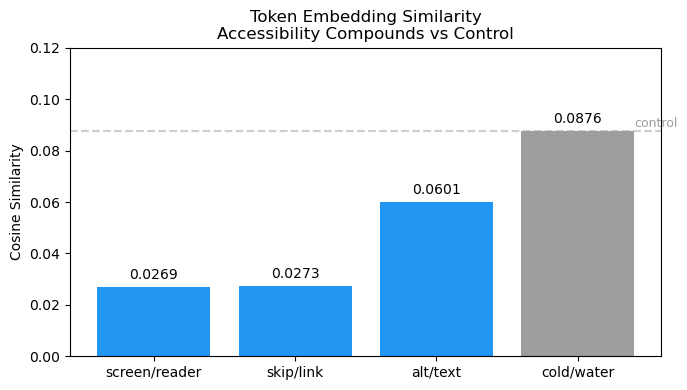

In [9]:
import matplotlib.pyplot as plt
import numpy as np

pairs = ['screen/reader', 'skip/link', 'alt/text', 'cold/water']
similarities = [0.0269, 0.0273, 0.0601, 0.0876]
colors = ['#2196F3', '#2196F3', '#2196F3', '#9E9E9E']  # blue for a11y, grey for control

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(pairs, similarities, color=colors)

ax.set_ylabel('Cosine Similarity')
ax.set_title('Token Embedding Similarity\nAccessibility Compounds vs Control', fontsize=12)
ax.set_ylim(0, 0.12)

# Add value labels on bars
for bar, val in zip(bars, similarities):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Add a note
ax.axhline(y=0.0876, color='#9E9E9E', linestyle='--', alpha=0.5)
ax.text(3.4, 0.089, 'control', fontsize=9, color='#9E9E9E')

plt.tight_layout()
plt.savefig('../paper/figures/embedding-similarity.png', dpi=150)
plt.show()

In [17]:
import torch

correct = "A screen reader is software that reads text aloud for blind users."
wrong = "A screen reader is a device for viewing screens."

def get_perplexity(model, text):
    tokens = model.to_tokens(text)
    logits = model(tokens)
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    
    # Get log prob of each actual next token
    token_log_probs = log_probs[0, :-1, :].gather(1, tokens[0, 1:].unsqueeze(1)).squeeze()
    
    # Perplexity = exp(-mean(log_probs))
    return torch.exp(-token_log_probs.mean()).item()

print(f"Correct: {get_perplexity(model, correct)}")
print(f"Wrong: {get_perplexity(model, wrong)}")

Correct: 106.73261260986328
Wrong: 41.36967086791992


### Attention Binding

In [28]:
import pandas as pd

prompt = "A screen reader is"
tokens = model.to_str_tokens(prompt)
print(list(enumerate(tokens)))  # verify indices

logits, cache = model.run_with_cache(prompt)

threshold = 0.1
rows = []

for layer in range(model.cfg.n_layers):
    attention = cache["pattern", layer]
    for head in range(model.cfg.n_heads):
        attn = attention[0, head]
        reader_idx = 3
        screen_idx = 2
        score = attn[reader_idx, screen_idx].item()
        if score > threshold:
            rows.append({
                "layer": layer,
                "head": head,
                "reader_to_screen": round(score, 4)
            })

df = pd.DataFrame(rows)
df.to_csv(f"../results/{model_name}/attention-binding.csv", index=False)


print("\nTop 10 by binding strength:")
sorted_rows = sorted(rows, key=lambda x: x["reader_to_screen"], reverse=True)
for row in sorted_rows[:10]:
    print(f"Layer {row['layer']:2d}, Head {row['head']:2d}: {row['reader_to_screen']}")    

print(f"\nFound {len(rows)} heads above threshold")
print(f"Saved to {out_path}")

[(0, '<|endoftext|>'), (1, 'A'), (2, ' screen'), (3, ' reader'), (4, ' is')]

Top 10 by binding strength:
Layer 11, Head  8: 1.0
Layer 11, Head  6: 0.9712
Layer  3, Head  0: 0.9243
Layer  3, Head  2: 0.9156
Layer  1, Head  1: 0.7337
Layer  7, Head  7: 0.6743
Layer  0, Head  0: 0.6281
Layer  1, Head  2: 0.6271
Layer  2, Head 11: 0.6195
Layer  2, Head  8: 0.5459

Found 46 heads above threshold
Saved to ../results/model_name/figures/attention-L11.html


In [34]:
import circuitsvis as cv

prompt = "A screen reader is"
tokens = model.to_str_tokens(prompt)
logits, cache = model.run_with_cache(prompt)

# Visualize attention for a specific layer (start with the last layer)
layer = 11
attention = cache["pattern", layer]  # shape: [heads, seq, seq]
print(f"Layer 11, Head 8")

html = cv.attention.attention_patterns(tokens=tokens, attention=attention[0])

# Save interactive HTML
out_path = "../results/pythia-160m/figures/attention-L11.html"
with open(out_path, "w") as f:
    f.write(str(html))
print(f"Saved to {out_path}")

html

Layer 11, Head 8
Saved to ../results/pythia-160m/figures/attention-L11.html


In [35]:
unload(model)

Model unloaded, memory cleared
